### Logistic Linear Regression:
This type of regression is used for classification 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df_from_csv = pd.read_csv("df = pd.read_csv("D:/University/ML Projects/Breast Cancer Dataset/data.csv")")
display(df_from_csv)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
df_from_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
df_from_csv.isnull().sum()


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [6]:
df_from_csv.duplicated().sum()

np.int64(0)

In [ ]:
x = df_from_csv.drop("target", axis = 1)
y = df_from_csv["target"]

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 32)

In [31]:
type(x_test)

pandas.DataFrame

In [32]:
display(x_train)
display(x_test)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
408,17.99,20.66,117.80,991.7,0.10360,0.13040,0.120100,0.088240,0.1992,0.06069,...,21.080,25.41,138.10,1349.0,0.14820,0.37350,0.33010,0.19740,0.3060,0.08503
298,14.26,18.17,91.22,633.1,0.06576,0.05220,0.024750,0.013740,0.1635,0.05586,...,16.220,25.26,105.80,819.7,0.09445,0.21670,0.15650,0.07530,0.2636,0.07676
282,19.40,18.18,127.20,1145.0,0.10370,0.14420,0.162600,0.094640,0.1893,0.05892,...,23.790,28.65,152.40,1628.0,0.15180,0.37490,0.43160,0.22520,0.3590,0.07787
199,14.45,20.22,94.49,642.7,0.09872,0.12060,0.118000,0.059800,0.1950,0.06466,...,18.330,30.12,117.90,1044.0,0.15520,0.40560,0.49670,0.18380,0.4753,0.10130
307,9.00,14.40,56.36,246.3,0.07005,0.03116,0.003681,0.003472,0.1788,0.06833,...,9.699,20.07,60.90,285.5,0.09861,0.05232,0.01472,0.01389,0.2991,0.07804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,19.73,19.82,130.70,1206.0,0.10620,0.18490,0.241700,0.097400,0.1733,0.06697,...,25.280,25.59,159.80,1933.0,0.17100,0.59550,0.84890,0.25070,0.2749,0.12970
403,12.94,16.17,83.18,507.6,0.09879,0.08836,0.032960,0.023900,0.1735,0.06200,...,13.860,23.02,89.69,580.9,0.11720,0.19580,0.18100,0.08388,0.3297,0.07834
88,12.36,21.80,79.78,466.1,0.08772,0.09445,0.060150,0.037450,0.1930,0.06404,...,13.830,30.50,91.46,574.7,0.13040,0.24630,0.24340,0.12050,0.2972,0.09261
310,11.70,19.11,74.33,418.7,0.08814,0.05253,0.015830,0.011480,0.1936,0.06128,...,12.610,26.55,80.92,483.1,0.12230,0.10870,0.07915,0.05741,0.3487,0.06958


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
216,11.890,18.35,77.32,432.2,0.09363,0.11540,0.066360,0.031420,0.1967,0.06314,...,13.25,27.10,86.20,531.2,0.14050,0.30460,0.28060,0.11380,0.3397,0.08365
440,10.970,17.20,71.73,371.5,0.08915,0.11130,0.094570,0.036130,0.1489,0.06640,...,12.36,26.87,90.14,476.4,0.13910,0.40820,0.47790,0.15550,0.2540,0.09532
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.007250,0.006250,0.1508,0.05376,...,14.91,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
16,14.680,20.13,94.74,684.5,0.09867,0.07200,0.073950,0.052590,0.1586,0.05922,...,19.07,30.88,123.40,1138.0,0.14640,0.18710,0.29140,0.16090,0.3029,0.08216
483,13.700,17.64,87.76,571.1,0.09950,0.07957,0.045480,0.031600,0.1732,0.06088,...,14.96,23.53,95.78,686.5,0.11990,0.13460,0.17420,0.09077,0.2518,0.06960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,9.876,19.40,63.95,298.3,0.10050,0.09697,0.061540,0.030290,0.1945,0.06322,...,10.76,26.83,72.22,361.2,0.15590,0.23020,0.26440,0.09749,0.2622,0.08490
332,11.220,19.86,71.94,387.3,0.10540,0.06779,0.005006,0.007583,0.1940,0.06028,...,11.98,25.78,76.91,436.1,0.14240,0.09669,0.01335,0.02022,0.3292,0.06522
519,12.750,16.70,82.51,493.8,0.11250,0.11170,0.038800,0.029950,0.2120,0.06623,...,14.45,21.74,93.63,624.1,0.14750,0.19790,0.14230,0.08045,0.3071,0.08557
379,11.080,18.83,73.30,361.6,0.12160,0.21540,0.168900,0.063670,0.2196,0.07950,...,13.24,32.82,91.76,508.1,0.21840,0.93790,0.84020,0.25240,0.4154,0.14030


In [34]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

display(x_train,x_test)

array([[ 1.11369962,  0.32228604,  1.07850587, ...,  1.28735999,
         0.23491182,  0.02863219],
       [ 0.0504453 , -0.24584785, -0.01954056, ..., -0.59926636,
        -0.43000188, -0.41418997],
       [ 1.51562685, -0.24356619,  1.46682929, ...,  1.71691128,
         1.06605395, -0.35475435],
       ...,
       [-0.49115878,  0.58239553, -0.49213842, ...,  0.09914077,
         0.09691086,  0.43450788],
       [-0.67929493, -0.0313716 , -0.71728338, ..., -0.87569343,
         0.9045301 , -0.79864743],
       [-1.08122217,  1.90804128, -1.07503665, ..., -0.35250614,
        -1.07296089, -0.08916814]], shape=(455, 30))

array([[-0.62513452, -0.20477793, -0.59376348, ..., -0.00438418,
         0.76339276, -0.04526075],
       [-0.88738492, -0.46716908, -0.82469198, ...,  0.63994275,
        -0.58054838,  0.57961648],
       [ 0.05899694, -0.55387225, -0.05754668, ..., -1.2477652 ,
        -0.70914018, -1.24735961],
       ...,
       [-0.37998742, -0.58125219, -0.37935938, ..., -0.51969121,
         0.25216194,  0.05754682],
       [-0.85602889, -0.09525814, -0.75983371, ...,  2.13719168,
         1.95051463,  2.98809785],
       [ 0.03334201,  0.29262443,  0.02961953, ...,  0.30619067,
        -0.58995754, -0.31673697]], shape=(114, 30))

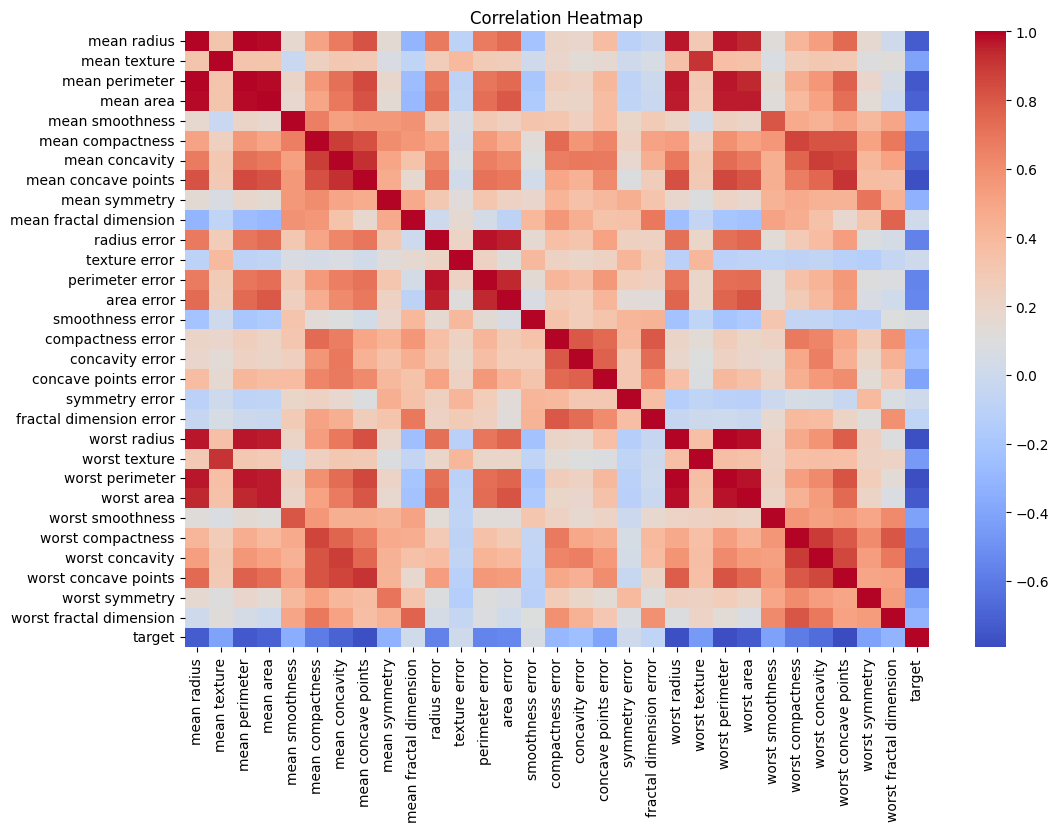

In [38]:
correlation_matrix = df_from_csv.corr()
plt.figure(figsize = (12, 8))
sns.heatmap (correlation_matrix, annot = False, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [39]:
model = LogisticRegression()
model.fit(x_train, y_train)

c:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [42]:
y_pred = model.predict(x_test)

In [46]:
accuracy = accuracy_score(y_test,y_pred)
print(f"The accuracy of this model is: {accuracy:.2f}")

The accuracy of this model is: 0.99


In [47]:
confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", confusion) 

Confusion Matrix: [[43  1]
 [ 0 70]]


class 0 = not cancer = -ve

class 1 = cancer = +ve


TP = Actual cancer samples were predicted as cancer

FP = Actual not cancer samples were predicted as cancer (Positive)

FN = Actual cancer samples were predicted as not cancer (Negative)

TN = Actual not cancer samples were predicted as not cancer

In [50]:
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.99      1.00      0.99        70

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

